In [10]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd

results_path = "../experiments/predictive_test_results.csv"
results_df = pd.read_csv(results_path)


In [3]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.100000,0.014970,2.216328e+01,2.217825e+01,4.833414,5.274447e+04,5.274931e+04,5000
1,theta_sweeps,5,0.112281,0.000059,9.490654e+00,9.490713e+00,13.136669,2.042106e+04,2.043420e+04,5000
2,theta_sweeps,5,0.124561,0.000158,5.795725e+01,5.795741e+01,11.117140,1.317719e+05,1.317830e+05,5000
3,theta_sweeps,5,0.136842,15.147497,7.820484e+04,7.821998e+04,28913.007750,1.550103e+08,1.550392e+08,5000
4,theta_sweeps,5,0.149123,0.000676,5.930292e+01,5.930360e+01,14.843330,1.287807e+05,1.287955e+05,5000
...,...,...,...,...,...,...,...,...,...,...
3595,theta_sweeps,200,4.950877,102.462215,2.407532e+05,2.408556e+05,8.801176,3.553071e+04,3.553951e+04,5000
3596,theta_sweeps,200,4.963158,140408.606870,6.989647e+08,6.991051e+08,18818.199680,9.244300e+07,9.246182e+07,5000
3597,theta_sweeps,200,4.975439,3.485835,4.784911e+04,4.785259e+04,0.037929,6.722542e+03,6.722579e+03,5000
3598,theta_sweeps,200,4.987719,29.830526,8.431866e+05,8.432164e+05,8.379545,1.182797e+05,1.182881e+05,5000


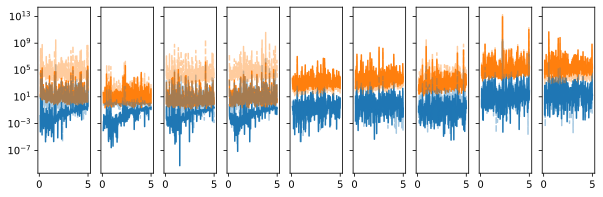

In [4]:


fig,axs = plt.subplots(figsize=(10,3),ncols = len(lengths), sharey=True)

for length in lengths:
    ax = axs[lengths==length][0]
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias,"C0", label="squared bias")
    ax.semilogy(theta, variance , "C1", label="variance")
    ax.plot(theta, ut_bias,"C0--", label="untrained squared bias",alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance",alpha=0.4)

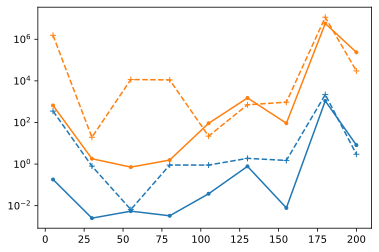

In [23]:
df = results_df[results_df.theta == results_df.theta.unique()[25]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  bias , "C0.-",label="squared bias")
ax.semilogy(lengths, variance , "C1.-",label="variance")

ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")